In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
import os

# Proje kök dizinini path'e ekle
sys.path.append(os.path.abspath('../src'))

# Uyarıları gizle
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [2]:
# Global olarak tanımla
from data_processing import CreditDataProcessor
from feature_engineering import CreditFeatureEngineer

# Global nesneler
processor = CreditDataProcessor()
fe = CreditFeatureEngineer()

print("Veri işleme sınıfları ve nesneleri başarıyla oluşturuldu!")

Veri işleme sınıfları ve nesneleri başarıyla oluşturuldu!


In [3]:
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('../')
data_path = project_root / 'data' / 'raw' / 'train.csv'

# Alternatif yollar listesi
alternative_paths = [
    data_path,
    Path('data/raw/train.csv'),
    Path('../data/raw/train.csv'),
    Path('../../data/raw/train.csv'),
    Path('./train.csv'),
    Path('../train.csv')
]

# Geçerli dosya yolunu bul
for path in alternative_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("train.csv bulunamadı. Dosya yolunu manuel belirtin.")

# Veriyi yükle
df_raw = processor.load_data(data_path)

print(f"✅ Ham veri yüklendi: {data_path}")
print(f"📊 Veri şekli: {df_raw.shape}")
display(df_raw.head())

Veri baÅŸarÄ±yla yÃ¼klendi. Boyut: (100000, 28)
✅ Ham veri yüklendi: c:\Users\PC\Desktop\creditwise\data\raw\train.csv
📊 Veri şekli: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
# Feature engineering nesnesini oluştur
fe = CreditFeatureEngineer()

# Konfigürasyon
config = {
    'advanced_features': True,      # Gelişmiş özellikler
    'binned_features': True,        # Gruplama özellikleri
    'interaction_features': False,  # Etkileşim özellikleri (çok fazla özellik oluşturabilir)
    'polynomial_features': False,   # Polinom özellikler (çok fazla özellik oluşturabilir)
    'scaling': 'standard',          # Ölçeklendirme yöntemi
    'feature_selection': True,      # Özellik seçimi
    'pca': False,                  # PCA uygulaması
    'k_best': 50                   # En iyi k özellik seçimi
}

print("=== KAPSAMLI VERİ İŞLEME BAŞLIYOR ===")
print("Konfigürasyon:")
for key, value in config.items():
    print(f"  {key}: {value}")

# 1. Temel veri işleme - DOĞRU METOD ADI
print("\n1. Temel veri işleme...")
df_processed = processor.clean_processing_pipeline(df_raw)  # ✅ Bu metod var

# 2. Feature engineering - METOD ADI KONTROL ET
print("\n2. Feature engineering...")
# feature_engineering.py dosyanızda hangi metod var kontrol edin
df_final = fe.minimal_pipeline(  # ✅ Bu metod var
    df_processed, 
    target_column='Credit_Score'
)

print(f"\n✅ Tüm işlemler tamamlandı!")
print(f"Final veri boyutu: {df_final.shape}")

=== KAPSAMLI VERİ İŞLEME BAŞLIYOR ===
Konfigürasyon:
  advanced_features: True
  binned_features: True
  interaction_features: False
  polynomial_features: False
  scaling: standard
  feature_selection: True
  pca: False
  k_best: 50

1. Temel veri işleme...
=== TEMÄ°Z VERÄ° Ä°ÅžLEME PIPELINE ===

=== VERÄ° BÄ°LGÄ°LERÄ° ===
Boyut: (100000, 28)
SÃ¼tun sayÄ±sÄ±: 28

Veri tipleri:
object     20
float64     4
int64       4
Name: count, dtype: int64

Eksik deÄŸer sayÄ±larÄ±:
Monthly_Inhand_Salary      15002
Type_of_Loan               11408
Name                        9985
Credit_History_Age          9030
Num_of_Delayed_Payment      7002
Amount_invested_monthly     4479
Num_Credit_Inquiries        1965
Monthly_Balance             1200
dtype: int64
=== EKSÄ°K DEÄžER Ä°ÅžLEME ===
Age: 4939 geÃ§ersiz deÄŸer NaN'a Ã§evrildi
Age: 0 eksik deÄŸer medyan (33.00) ile dolduruldu
Annual_Income: 6980 geÃ§ersiz deÄŸer NaN'a Ã§evrildi
Annual_Income: 0 eksik deÄŸer medyan (37550.74) ile dolduruldu
Monthly_

In [5]:
project_root = Path.cwd().resolve().parent.parent
# Final veriyi kaydet (tek dosya)
final_data_path =  project_root / 'creditwise'  / 'data' / 'processed' / 'train_processed.csv'
df_final.to_csv(final_data_path, index=False)
print(f"✅ Makine öğrenmesi için hazır veri kaydedildi: {final_data_path}")
print(f"📊 Boyut: {df_final.shape}")
print(f"🎯 Hedef sütun: Credit_Score")

✅ Makine öğrenmesi için hazır veri kaydedildi: C:\Users\PC\Desktop\creditwise\data\processed\train_processed.csv
📊 Boyut: (100000, 37)
🎯 Hedef sütun: Credit_Score


In [6]:
# Kapsamlı karşılaştırma
print("=== HAM VERİ vs FİNAL VERİ KARŞILAŞTIRMASI ===")
print(f"Ham veri boyutu: {df_raw.shape}")
print(f"Final veri boyutu: {df_final.shape}")
print(f"Satır kaybı: {df_raw.shape[0] - df_final.shape[0]} ({((df_raw.shape[0] - df_final.shape[0]) / df_raw.shape[0] * 100):.2f}%)")
print(f"Özellik artışı: {df_final.shape[1] - df_raw.shape[1]}")

# Eksik değer durumu
print(f"\nEksik değer sayıları:")
print(f"Ham veri: {df_raw.isnull().sum().sum()}")
print(f"Final veri: {df_final.isnull().sum().sum()}")

# Veri tipleri
print(f"\nVeri tipleri (Final):")
print(df_final.dtypes.value_counts())

=== HAM VERİ vs FİNAL VERİ KARŞILAŞTIRMASI ===
Ham veri boyutu: (100000, 28)
Final veri boyutu: (100000, 37)
Satır kaybı: 0 (0.00%)
Özellik artışı: 9

Eksik değer sayıları:
Ham veri: 60071
Final veri: 9985

Veri tipleri (Final):
float64    25
object     12
Name: count, dtype: int64


In [7]:
# Final veri hakkında detaylı bilgi
print("=== FİNAL VERİ ANALİZİ ===")
print(f"Final boyut: {df_final.shape}")
print(f"Toplam özellik sayısı: {df_final.shape[1] - 1}")  # Target hariç

# Sayısal ve kategorik sütun sayıları
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
categorical_cols = df_final.select_dtypes(include=['object']).columns

print(f"Sayısal sütun sayısı: {len(numeric_cols)}")
print(f"Kategorik sütun sayısı: {len(categorical_cols)}")

# Veri tipleri dağılımı
print(f"\nVeri tipleri:")
print(df_final.dtypes.value_counts())

# Memory usage
memory_usage = df_final.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory kullanımı: {memory_usage:.2f} MB")

=== FİNAL VERİ ANALİZİ ===
Final boyut: (100000, 37)
Toplam özellik sayısı: 36
Sayısal sütun sayısı: 25
Kategorik sütun sayısı: 12

Veri tipleri:
float64    25
object     12
Name: count, dtype: int64

Memory kullanımı: 100.76 MB


Feature names uzunluğu: 25
Feature scores uzunluğu: 29
Selected mask uzunluğu: 29
Feature scores 25 uzunluğuna kırpıldı
Selected mask 25 uzunluğuna kırpıldı

=== EN ÖNEMLİ ÖZELLİKLER ===
Seçilen özellik sayısı: 21
                      Feature         Score  Selected
19         Credit_Mix_Numeric  13671.399591      True
7         Delay_from_due_date  11471.888723      True
5               Interest_Rate  10290.668908      True
18         Payment_Min_Binary  10146.425465      True
11           Outstanding_Debt   9006.870467      True
16  Credit_History_Age_Months   5268.161030      True
9        Changed_Credit_Limit   2615.878666      True
15            Monthly_Balance   2150.542841      True
2       Monthly_Inhand_Salary   1903.068037      True
14    Amount_invested_monthly   1148.330849      True
0                         Age    599.887378      True
20  Payment_Behaviour_Encoded    508.708251      True
12   Credit_Utilization_Ratio    105.296722      True
17              Month_Numeric 

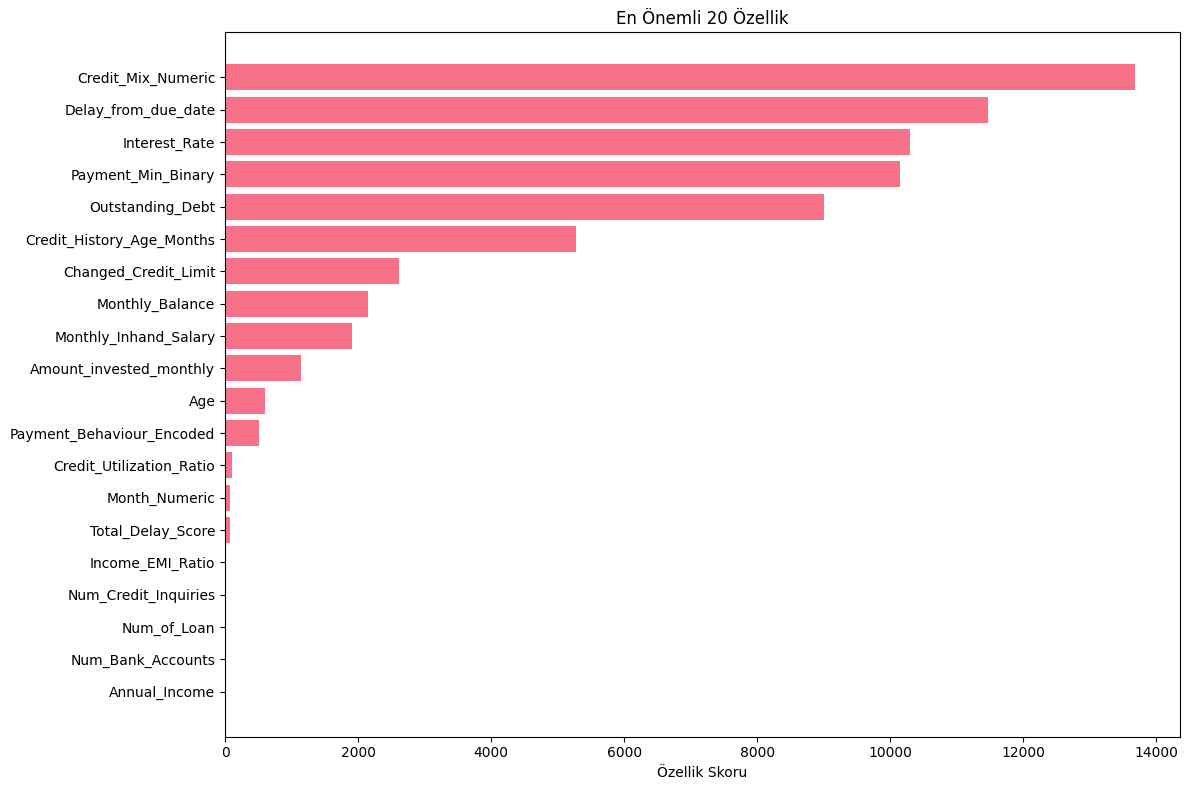

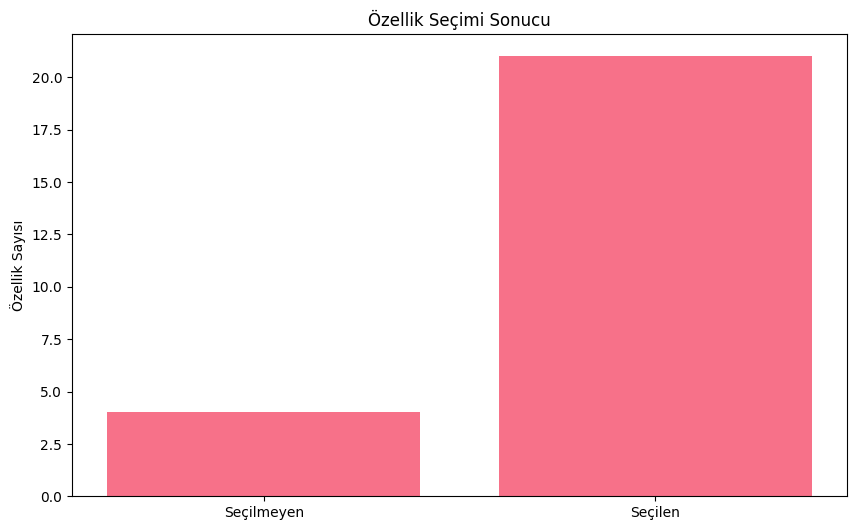

In [8]:
# Özellik seçimi uygulandıysa, seçilen özellikleri göster
if fe.feature_selector is not None:
    # Önce hangi veri setinin kullanıldığını kontrol edelim
    # Eğer X_train varsa onu kullan, yoksa df_processed'den numeric features al
    
    try:
        # Eğer X_train mevcutsa
        if 'X_train' in globals():
            feature_names = X_train.columns.tolist()
        elif 'X' in globals():
            feature_names = X.columns.tolist()
        else:
            # df_processed'den numeric özellikleri al
            numeric_features = df_processed.select_dtypes(include=[np.number]).columns.tolist()
            
            # Credit_Score'u çıkar (hedef değişken)
            if 'Credit_Score' in numeric_features:
                numeric_features.remove('Credit_Score')
            
            feature_names = numeric_features
        
        # Özellik skorları ve seçim maskesi
        feature_scores = fe.feature_selector.scores_
        selected_mask = fe.feature_selector.get_support()
        
        # Uzunlukları kontrol et ve yazdır
        print(f"Feature names uzunluğu: {len(feature_names)}")
        print(f"Feature scores uzunluğu: {len(feature_scores)}")
        print(f"Selected mask uzunluğu: {len(selected_mask)}")
        
        # Uzunluklar uyuşmuyorsa, en kısa olana göre kırp
        min_length = min(len(feature_names), len(feature_scores), len(selected_mask))
        
        if min_length < len(feature_names):
            feature_names = feature_names[:min_length]
            print(f"Feature names {min_length} uzunluğuna kırpıldı")
            
        if min_length < len(feature_scores):
            feature_scores = feature_scores[:min_length]
            print(f"Feature scores {min_length} uzunluğuna kırpıldı")
            
        if min_length < len(selected_mask):
            selected_mask = selected_mask[:min_length]
            print(f"Selected mask {min_length} uzunluğuna kırpıldı")
        
        # DataFrame oluştur
        selected_features = pd.DataFrame({
            'Feature': feature_names,
            'Score': feature_scores,
            'Selected': selected_mask
        }).sort_values('Score', ascending=False)
        
        print("\n=== EN ÖNEMLİ ÖZELLİKLER ===")
        selected_only = selected_features[selected_features['Selected']]
        print(f"Seçilen özellik sayısı: {len(selected_only)}")
        print(selected_only.head(15))
        
        # Görselleştirme
        if len(selected_only) > 0:
            plt.figure(figsize=(12, 8))
            top_features = selected_only.head(20)
            
            plt.barh(range(len(top_features)), top_features['Score'])
            plt.yticks(range(len(top_features)), top_features['Feature'])
            plt.xlabel('Özellik Skoru')
            plt.title(f'En Önemli {len(top_features)} Özellik')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
            
            # Seçilen ve seçilmeyen özelliklerin dağılımı
            plt.figure(figsize=(10, 6))
            selection_counts = selected_features['Selected'].value_counts()
            plt.bar(['Seçilmeyen', 'Seçilen'], [selection_counts[False], selection_counts[True]])
            plt.title('Özellik Seçimi Sonucu')
            plt.ylabel('Özellik Sayısı')
            plt.show()
            
        else:
            print("Hiçbir özellik seçilmedi!")
    
    except Exception as e:
        print(f"Hata oluştu: {e}")
        print("Alternatif yöntem deneniyor...")
        
        # Alternatif: feature_selector'un input_features_in_ özelliğini kullan
        try:
            if hasattr(fe.feature_selector, 'feature_names_in_'):
                feature_names = fe.feature_selector.feature_names_in_.tolist()
            else:
                # Son çare: numeric features kullan
                numeric_features = df_processed.select_dtypes(include=[np.number]).columns.tolist()
                if 'Credit_Score' in numeric_features:
                    numeric_features.remove('Credit_Score')
                feature_names = numeric_features
            
            print(f"Alternatif yöntemle {len(feature_names)} özellik bulundu")
            print("İlk 10 özellik:", feature_names[:10])
            
        except Exception as e2:
            print(f"Alternatif yöntem de başarısız: {e2}")
            
else:
    print("Özellik seçimi uygulanmadı.")

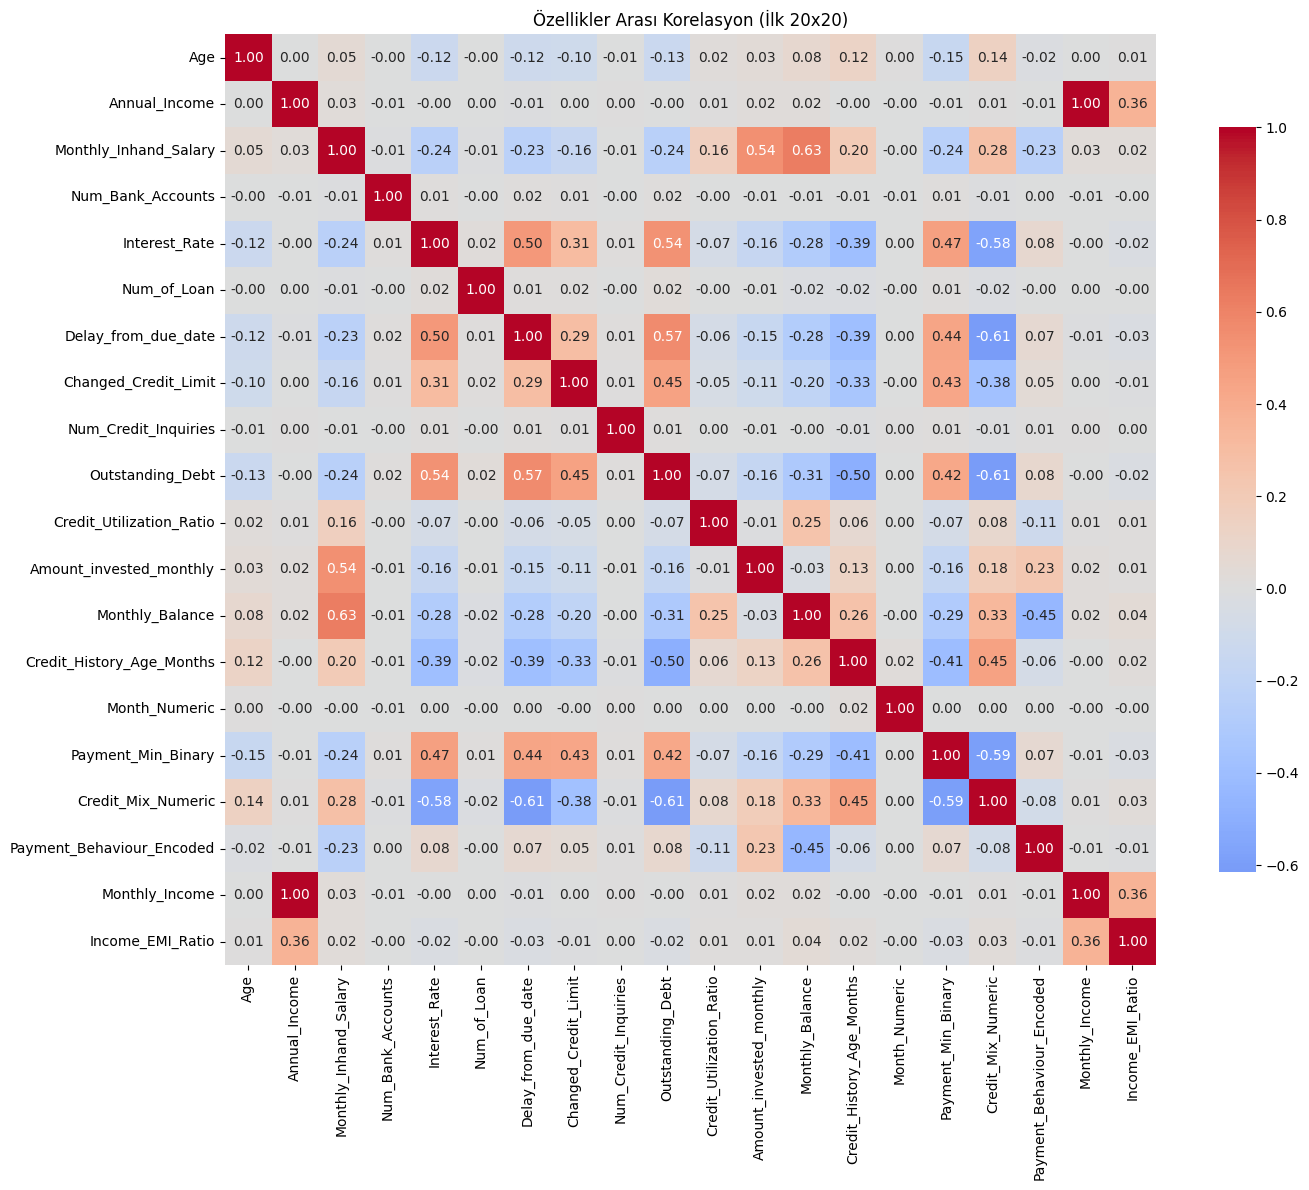


=== CREDIT_SCORE İLE EN YÜKSEK KORELASYONLU ÖZELLİKLER ===
Credit_Mix_Numeric           0.445517
Delay_from_due_date         -0.431591
Interest_Rate               -0.412997
Outstanding_Debt            -0.384583
Payment_Min_Binary          -0.384088
Combined_Risk_Score         -0.315139
Credit_History_Age_Months    0.308742
Debt_Income_Ratio           -0.296847
Monthly_Balance              0.203042
Monthly_Inhand_Salary        0.190585
Changed_Credit_Limit        -0.167634
Amount_invested_monthly      0.147140
Age_Income_Score             0.138904
Age                          0.108107
Payment_Behaviour_Encoded   -0.100212
dtype: float64


In [9]:
# Sayısal özelliklerin korelasyon analizi
numeric_features = df_final.select_dtypes(include=[np.number])

if len(numeric_features.columns) > 1:
    plt.figure(figsize=(15, 12))
    correlation_matrix = numeric_features.corr()
    
    # Sadece en yüksek korelasyonlu özellikleri göster (ilk 20x20)
    top_corr = correlation_matrix.iloc[:20, :20]
    
    sns.heatmap(top_corr, 
                annot=True, 
                cmap='coolwarm', 
                center=0, 
                square=True,
                fmt='.2f',
                cbar_kws={'shrink': 0.8})
    plt.title('Özellikler Arası Korelasyon (İlk 20x20)')
    plt.tight_layout()
    plt.show()
    
    # Credit_Score ile en yüksek korelasyonlu özellikler
    if 'Credit_Score' in df_final.columns:
        # Credit_Score'u sayısal değere dönüştür
        credit_score_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
        df_temp = df_final.copy()
        df_temp['Credit_Score_Numeric'] = df_temp['Credit_Score'].map(credit_score_mapping)
        
        correlations_with_target = df_temp.select_dtypes(include=[np.number]).corrwith(df_temp['Credit_Score_Numeric'])
        correlations_with_target = correlations_with_target.drop('Credit_Score_Numeric').sort_values(key=abs, ascending=False)
        
        print("\n=== CREDIT_SCORE İLE EN YÜKSEK KORELASYONLU ÖZELLİKLER ===")
        print(correlations_with_target.head(15))
else:
    print("Korelasyon analizi için yeterli sayısal özellik yok.")

In [10]:
print("=== KAPSAMLI VERİ İŞLEME ÖZETİ ===")
print(f"📊 Ham veri boyutu: {df_raw.shape}")
print(f"🎯 Final veri boyutu: {df_final.shape}")
print(f"📈 Özellik artışı: {df_final.shape[1] - df_raw.shape[1]}")
print(f"📉 Satır kaybı: {df_raw.shape[0] - df_final.shape[0]} ({((df_raw.shape[0] - df_final.shape[0]) / df_raw.shape[0] * 100):.2f}%)")
print(f"✅ Veri kalitesi: {'Eksik değer yok' if df_final.isnull().sum().sum() == 0 else f'Kalan eksik değer: {df_final.isnull().sum().sum()}'}")

print("\n=== OLUŞTURULAN DOSYA ===")
print(f"📁 Makine öğrenmesi için hazır veri: {final_data_path}")
print(f"💾 Boyut: {df_final.shape[0]:,} satır × {df_final.shape[1]} sütun")

print("\n=== UYGULANAN İŞLEMLER ===")
print("✅ 1. Eksik değer işleme (median/mode imputation)")
print("✅ 2. Sayısal sütun temizleme (outlier handling)")
print("✅ 3. Kategorik kodlama (binary, ordinal, one-hot)")
print("✅ 4. Özellik oluşturma (ratio, interaction features)")
print("✅ 5. Gelişmiş feature engineering")
print("✅ 6. Gruplama özellikleri (binning)")
print("✅ 7. Özellik ölçeklendirme (StandardScaler)")
print("✅ 8. Özellik seçimi (SelectKBest)")
print("✅ 9. Outlier removal")

print("\n=== SONRAKİ ADIMLAR ===")
print("🚀 1. 03_modeling.ipynb notebook'unu çalıştırabilirsiniz")
print("🤖 2. Farklı ML algoritmaları test edebilirsiniz:")
print("     • RandomForest, XGBoost, LightGBM")
print("     • SVM, Logistic Regression")
print("     • Neural Networks")
print("🔧 3. Hyperparameter tuning yapabilirsiniz")
print("📊 4. Cross-validation ile model performansını değerlendirebilirsiniz")

print("\n🎉 Veri tamamen makine öğrenmesi için hazır!")

=== KAPSAMLI VERİ İŞLEME ÖZETİ ===
📊 Ham veri boyutu: (100000, 28)
🎯 Final veri boyutu: (100000, 37)
📈 Özellik artışı: 9
📉 Satır kaybı: 0 (0.00%)
✅ Veri kalitesi: Kalan eksik değer: 9985

=== OLUŞTURULAN DOSYA ===
📁 Makine öğrenmesi için hazır veri: C:\Users\PC\Desktop\creditwise\data\processed\train_processed.csv
💾 Boyut: 100,000 satır × 37 sütun

=== UYGULANAN İŞLEMLER ===
✅ 1. Eksik değer işleme (median/mode imputation)
✅ 2. Sayısal sütun temizleme (outlier handling)
✅ 3. Kategorik kodlama (binary, ordinal, one-hot)
✅ 4. Özellik oluşturma (ratio, interaction features)
✅ 5. Gelişmiş feature engineering
✅ 6. Gruplama özellikleri (binning)
✅ 7. Özellik ölçeklendirme (StandardScaler)
✅ 8. Özellik seçimi (SelectKBest)
✅ 9. Outlier removal

=== SONRAKİ ADIMLAR ===
🚀 1. 03_modeling.ipynb notebook'unu çalıştırabilirsiniz
🤖 2. Farklı ML algoritmaları test edebilirsiniz:
     • RandomForest, XGBoost, LightGBM
     • SVM, Logistic Regression
     • Neural Networks
🔧 3. Hyperparameter tuning ya

# �� TEST VERİLERİNE GEÇİŞ

---

## �� **Şu ana kadar yapılanlar:**
✅ Eğitim verisi yüklendi ve işlendi  
✅ Feature engineering uygulandı  
✅ Eğitim verisi kaydedildi  

## 🎯 **Şimdi yapılacaklar:**
�� Test verisi yükleniyor  
�� Test verisi aynı işlemlerden geçiriliyor  
�� Test verisi kaydediliyor  

---

**Not:** Test verilerine eğitim verilerinde kullanılan **aynı pipeline** uygulanacak.

In [11]:
# Test verilerini yükle
print("=== TEST VERİLERİ YÜKLENİYOR ===")
test_data_path = project_root / 'data' / 'raw' / 'test.csv'

# Alternatif yollar listesi (test için)
test_alternative_paths = [
    test_data_path,
    Path('data/raw/test.csv'),
    Path('../data/raw/test.csv'),
    Path('../../data/raw/test.csv'),
    Path('./test.csv'),
    Path('../test.csv')
]

# Geçerli test dosya yolunu bul
for path in test_alternative_paths:
    if path.exists():
        test_data_path = path
        break
else:
    raise FileNotFoundError("test.csv bulunamadı. Dosya yolunu manuel belirtin.")

# Test verisini yükle
df_test_raw = processor.load_data(test_data_path)

print(f"✅ Test verisi yüklendi: {test_data_path}")
print(f"�� Test veri şekli: {df_test_raw.shape}")
display(df_test_raw.head())

=== TEST VERİLERİ YÜKLENİYOR ===
Veri baÅŸarÄ±yla yÃ¼klendi. Boyut: (50000, 27)
✅ Test verisi yüklendi: ..\data\raw\test.csv
�� Test veri şekli: (50000, 27)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [13]:
# Test verilerini aynı pipeline ile işle
print("=== TEST VERİLERİ ÖN İŞLEME ===")

print("1. Temel veri işleme...")
df_test_processed = processor.clean_processing_pipeline(df_test_raw)  # ✅ Değiştirildi

print("1.1. Test verisi outlier kontrolü...")
if 'Age' in df_test_processed.columns:
    df_test_processed.loc[df_test_processed['Age'] > 100, 'Age'] = 100
    df_test_processed.loc[df_test_processed['Age'] < 18, 'Age'] = 18

if 'Annual_Income' in df_test_processed.columns:
    income_99 = df_test_processed['Annual_Income'].quantile(0.99)
    df_test_processed.loc[df_test_processed['Annual_Income'] > income_99, 'Annual_Income'] = income_99

print(f"✅ Test verisi işlendi!")
print(f"İşlenmiş test veri boyutu: {df_test_processed.shape}")

=== TEST VERİLERİ ÖN İŞLEME ===
1. Temel veri işleme...
=== TEMÄ°Z VERÄ° Ä°ÅžLEME PIPELINE ===

=== VERÄ° BÄ°LGÄ°LERÄ° ===
Boyut: (50000, 27)
SÃ¼tun sayÄ±sÄ±: 27

Veri tipleri:
object     19
float64     4
int64       4
Name: count, dtype: int64

Eksik deÄŸer sayÄ±larÄ±:
Monthly_Inhand_Salary      7498
Type_of_Loan               5704
Name                       5015
Credit_History_Age         4470
Num_of_Delayed_Payment     3498
Amount_invested_monthly    2271
Num_Credit_Inquiries       1035
Monthly_Balance             562
dtype: int64
=== EKSÄ°K DEÄžER Ä°ÅžLEME ===
Age: 2477 geÃ§ersiz deÄŸer NaN'a Ã§evrildi
Age: 0 eksik deÄŸer medyan (34.00) ile dolduruldu
Annual_Income: 3520 geÃ§ersiz deÄŸer NaN'a Ã§evrildi
Annual_Income: 0 eksik deÄŸer medyan (37575.87) ile dolduruldu
Monthly_Inhand_Salary: 0 eksik deÄŸer medyan (3086.30) ile dolduruldu
Num_of_Loan: 2436 geÃ§ersiz deÄŸer NaN'a Ã§evrildi
Num_of_Loan: 0 eksik deÄŸer medyan (3.00) ile dolduruldu
Num_of_Delayed_Payment: 1427 geÃ§ersiz deÄ

In [15]:
# Test verilerine feature engineering uygula (target_column olmadan)
print("=== TEST VERİLERİNE FEATURE ENGINEERING ===")
print("2. Feature engineering...")

# Test verilerinde target column olmadığı için None olarak belirt
df_test_final = fe.minimal_pipeline(  # ✅ DOĞRU METOD ADI
    df_test_processed, 
    target_column=None  # Test verisinde target yok
)

print(f"✅ Test verisi feature engineering tamamlandı!")
print(f"Final test veri boyutu: {df_test_final.shape}")

=== TEST VERİLERİNE FEATURE ENGINEERING ===
2. Feature engineering...
=== MÄ°NÄ°MAL Ã–ZELLÄ°K MÃœHENDÄ°SLÄ°ÄžÄ° PIPELINE ===

BaÅŸlangÄ±Ã§ boyutu: (50000, 36)
Hedef sÃ¼tun belirtilmedi veya bulunamadÄ±
=== MÄ°NÄ°MAL Ã–ZELLÄ°K OLUÅžTURMA ===
Debt_Income_Ratio oluÅŸturuldu
Age_Income_Score oluÅŸturuldu
Credit_Product_Density oluÅŸturuldu
Combined_Risk_Score oluÅŸturuldu
  Credit_Product_Density sÃ¼tununda 16 infinity deÄŸer bulundu
    Credit_Product_Density: infinity deÄŸerler 1.40 ile deÄŸiÅŸtirildi
Kalan NaN deÄŸerler temizleniyor:
Toplam 4 minimal Ã¶zellik oluÅŸturuldu
=== GÃœVENLÄ° Ã–ZELLÄ°K Ã–LÃ‡EKLENDÄ°RME (STANDARD) ===
Infinity deÄŸer bulunamadÄ±
Kalan NaN deÄŸerler temizleniyor:
29 Ã¶zellik Ã¶lÃ§eklendirildi
Ã‡ok fazla Ã¶zellik var, Ã¶zellik seÃ§imi yapÄ±lÄ±yor...
=== Ã–ZELLÄ°K SEÃ‡Ä°MÄ° (F_CLASSIF, k=25) ===
Hedef sÃ¼tun 'None' bulunamadÄ±
Infinity deÄŸer bulunamadÄ±
Kalan NaN deÄŸerler temizleniyor:

=== MÄ°NÄ°MAL Ã–ZELLÄ°K MÃœHENDÄ°SLÄ°ÄžÄ° TAMAMLANDI ===
BaÅŸlangÄ±Ã§ Ã¶zell

In [16]:
# Test verisini kaydet
print("=== TEST VERİSİ KAYDEDİLİYOR ===")
test_final_path = project_root / 'creditwise' /'data' / 'processed' / 'test_processed.csv'
df_test_final.to_csv(test_final_path, index=False)

print(f"✅ Test verisi makine öğrenmesi için hazır: {test_final_path}")
print(f"📊 Boyut: {df_test_final.shape}")

=== TEST VERİSİ KAYDEDİLİYOR ===
✅ Test verisi makine öğrenmesi için hazır: C:\Users\PC\Desktop\creditwise\data\processed\test_processed.csv
📊 Boyut: (50000, 40)


In [17]:
# Eğitim ve test verileri karşılaştırması
print("=== EĞİTİM vs TEST VERİLERİ KARŞILAŞTIRMASI ===")
print(f"Eğitim verisi boyutu: {df_final.shape}")
print(f"Test verisi boyutu: {df_test_final.shape}")

# Özellik sayısı kontrolü
print(f"\nÖzellik sayıları:")
print(f"Eğitim verisi: {df_final.shape[1]}")
print(f"Test verisi: {df_test_final.shape[1]}")

# Özellik isimleri kontrolü
train_features = set(df_final.columns)
test_features = set(df_test_final.columns)

print(f"\nÖzellik isimleri eşleşiyor mu: {train_features == test_features}")

if train_features != test_features:
    print(f"\nEğitim verisinde olup test verisinde olmayan özellikler:")
    print(train_features - test_features)
    print(f"\nTest verisinde olup eğitim verisinde olmayan özellikler:")
    print(test_features - train_features)

# Eksik değer durumu
print(f"\nEksik değer sayıları:")
print(f"Eğitim verisi: {df_final.isnull().sum().sum()}")
print(f"Test verisi: {df_test_final.isnull().sum().sum()}")

=== EĞİTİM vs TEST VERİLERİ KARŞILAŞTIRMASI ===
Eğitim verisi boyutu: (100000, 37)
Test verisi boyutu: (50000, 40)

Özellik sayıları:
Eğitim verisi: 37
Test verisi: 40

Özellik isimleri eşleşiyor mu: False

Eğitim verisinde olup test verisinde olmayan özellikler:
{'Credit_Score'}

Test verisinde olup eğitim verisinde olmayan özellikler:
{'Total_EMI_per_month', 'Occupation_Encoded', 'Num_of_Delayed_Payment', 'Num_Credit_Card'}

Eksik değer sayıları:
Eğitim verisi: 9985
Test verisi: 5015
